# Notebook A: Candlekeep MVP - Prototype

In this notebook you test whether **Candlekeep’s** routing prototype is strong enough to move forward.

Candlekeep handles **20,000+ customer messages per month**, with roughly **60 hours of manual processing per week** and an average **4.2-hour first response time**. If routing can be automated **safely** and **affordably**, the team can reduce manual effort and speed up handling.

Your job is **not** to prove perfection. Your job is to decide whether this setup is good enough to **continue**, **improve and re-test**, or **stop** — using evidence from a fixed offline evaluation set.

## What this notebook evaluates

1. **Routing quality** — Does the model route to the right department often enough to be useful?
2. **Safety** — If we only automate the safest-looking cases, how risky is that?
3. **Cost** — Is estimated cost acceptable at Candlekeep scale?
4. **Speed** — Is the system fast enough to support a better workflow?

You will **compare** a few candidate models on a sample, **choose** one to study further, then **run a full evaluation** on that model.

## Environment

- **Colab / remote:** uncomment the GitHub install line below (and restart the runtime if prompted).
- **Local (repo):** uncomment the editable install from the repo root, or ensure `src/` is on `PYTHONPATH`.

Keep your API key in **Secrets** (Colab) or a local **`.env`** file — avoid committing real keys.

```python
# Local dev (repo root) — uncomment if working from a local clone:
%pip install -q -e .
```

In [45]:
# Colab / remote — uncomment if running in Colab or a fresh environment:

%pip install -q git+https://github.com/mnrozhkov/ai_leader.git

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Configure the experiment

Set your API key and the main settings. You can change **candidate models**, **temperature**, **`MONTHLY_MESSAGES`** (for cost projection), and **`SYSTEM_PROMPT`** (default is the course routing baseline).

For model comparison we use **30%** of the rows (`random_state=42`) so runs stay tractable; the **full dataset** is used in Step 4.

In [46]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
from pathlib import Path

from dotenv import load_dotenv

_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "src" / "ai_leader").is_dir() else _cwd.parent
if (ROOT / "src" / "ai_leader").is_dir() and str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ai_leader import (  # noqa: E402
    DEFAULT_SYSTEM_PROMPT,
    Thresholds,
    build_model_comparison_dataframe,
    compute_safety_metrics,
    create_client,
    evaluate_decision,
    evaluate_model_on_dataframe_async,
    load_and_validate_dataset,
    run_model_comparison_async,
    select_best_model,
)
from ai_leader.reporting import (  # noqa: E402
    display_cost_breakdown,
    display_cost_metrics,
    display_cost_projection,
    display_latency_metrics,
    display_mvp_decision,
    display_quality_metrics,
    display_safety_metrics,
    plot_quality_vs_cost,
    plot_safety_comparison,
    show_figure,
)

load_dotenv(ROOT / ".env" if (ROOT / ".env").is_file() else ".env", override=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

## Settings

### API key

This notebook calls the Nebius inference API (**Token Factory**, OpenAI-compatible).  
Get your key at: https://studio.nebius.ai -> Settings -> API Keys (or https://tokenfactory.nebius.com).  
Store it as a Colab Secret named `NEBIUS_API_KEY`, or add it to a local `.env` file.  
Do **not** paste a real key directly into the notebook — the cell below prompts you interactively as a fallback only.

After the setup cell runs, `!env | grep NEBIUS_API_KEY` can show the key in the process environment (the cell copies it into `os.environ` for this session).

**401 / Couldn't authenticate:** use a Nebius **inference** API key (not an OpenAI key). This project routes some models to the US Token Factory host; if your key/project is in **EU**, set `TOKENFACTORY_BASE_URL` to the EU endpoint (see commented lines in the setup cell) or see [Nebius API authentication](https://docs.nebius.com/studio/api/authentication).


In [47]:
# Colab: use Secrets / env, or paste when prompted (fallback).
# Primary env var: NEBIUS_API_KEY (see Nebius docs).
# Optional: OPENAI_API_KEY for other OpenAI-compatible hosts.

api_key = os.getenv("NEBIUS_API_KEY") or os.getenv("OPENAI_API_KEY") or ""
if not api_key:
    api_key = input("Paste Nebius API key (or set env): ").strip()
    os.environ["NEBIUS_API_KEY"] = api_key

DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

TEMPERATURE = 0.1
MONTHLY_MESSAGES = 20_000

DECISION_THRESHOLDS = Thresholds(
    department_accuracy_pass=0.85,
    category_accuracy_pass=0.85,
    unsafe_auto_route_rate_pass=0.03,
    monthly_cost_usd_pass=1_000.0,
    p95_latency_ms_pass=5_000.0,
)

## Step 2 — Load the evaluation dataset

The CSV holds labeled customer requests with **gold routing targets** (department, category, etc.). We use it to measure how the routing prototype performs beyond a handful of ad-hoc examples.

**Where the file comes from:** the path is set in the previous cell as `DATASET_URL`. By default that is a published Google Sheet CSV URL. To use a **local copy** instead (offline runs or if the URL changes), set the environment variable `AI_LEADER_DATASET_PATH` to a `.csv` file path before running the load cell — the same variable name is read in Settings.

If loading fails, the next cell raises a short error that repeats the URL or path you tried.

In [48]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** inspect how departments are distributed in the reference labels.

In [49]:
df["Routing to Department"].value_counts()

Routing to Department
Logistics           29
Customer Support    27
Product Team        23
Returns             21
Name: count, dtype: int64

In [50]:
df["Category"].value_counts()

Category
Delivery            28
Order Issue         27
General Feedback    24
Payment             21
Name: count, dtype: int64

## Step 3 — Compare candidate models

On a **random sample** of the dataset, run all candidates and build a comparison table.

The table and charts use the **same column set** as `scripts/run_notebook_a.py` (`comparison_table.csv`) when `show_all=True`, including safety metrics, so **quality vs cost** and **safety bars** match that tool. Numbers still differ if the CLI run uses the full sheet or a different fixture while this step uses the 30% sample.

### Metric primer (used in Notebook A and B)

- **`department_accuracy`**  
  Meaning: share of rows with correct routed department.  
  Formula: `(# rows where predicted department == gold department) / total_rows`.  
  Interpretation: higher is better; this is the main routing KPI.

- **`category_accuracy`**  
  Meaning: share of rows with correct category label.  
  Formula: `(# rows where predicted category == gold category) / total_rows`.  
  Interpretation: higher is better; useful secondary signal, but less critical than department routing.

- **`unsafe_auto_route_rate`**  
  Meaning: among rows the policy would auto-route, how many are wrong routes.  
  Formula: `(# wrong routes inside auto-routed subset) / (# auto-routed rows)`.  
  Interpretation: lower is better; this is the key safety guardrail for automation.

- **`monthly_cost_usd`**  
  Meaning: projected monthly inference spend at configured volume.  
  Formula: `cost_per_message_usd * MONTHLY_MESSAGES`.  
  Interpretation: lower is better, but evaluate together with quality/safety (cheap but wrong is not acceptable).

- **`p95_latency_ms`**  
  Meaning: 95th percentile model latency in milliseconds.  
  Formula: sort per-row latencies; take the value at the 95th percentile.  
  Interpretation: lower is better; captures tail latency (worst-case user experience) better than median alone.

**Suggested model:** lowest **misroute rate**. Tie-breakers: **higher** department accuracy, then **lower** cost per message, then **lower** median latency.

The notebook can suggest a model automatically; you may **override** `MODEL_TO_EVALUATE` if you have a clear reason.



In [51]:
print(DEFAULT_SYSTEM_PROMPT)

You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.


In [52]:
CANDIDATE_MODELS = [
    "deepseek-ai/DeepSeek-V3.2",
    "zai-org/GLM-5",
    "openai/gpt-oss-120b",
    "Qwen/Qwen3.5-397B-A17B-fast",
]

model_runs = await run_model_comparison_async(
    df=df.sample(frac=0.3, random_state=42),
    models=CANDIDATE_MODELS,
    api_key=api_key,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running deepseek-ai/DeepSeek-V3.2:   0%|          | 0/30 [00:00<?, ?row/s]

Running zai-org/GLM-5:   0%|          | 0/30 [00:00<?, ?row/s]

Running openai/gpt-oss-120b:   0%|          | 0/30 [00:00<?, ?row/s]

Running Qwen/Qwen3.5-397B-A17B-fast:   0%|          | 0/30 [00:00<?, ?row/s]

Row 30 skipped — TimeoutError after 30s
Row 30 failed after retries (TimeoutError: ) — skipping
Skipped 1 / 30 rows due to errors


In [53]:
comparison_df = build_model_comparison_dataframe(df, model_runs, show_all=True)
comparison_df

,model,department_accuracy,misroute_rate,category_accuracy,cost_per_message_usd,monthly_cost_usd,cost_source,median_latency_ms,p95_latency_ms,latency_source,auto_route_coverage,auto_route_precision,unsafe_auto_route_rate,manual_review_rate
0,deepseek-ai/DeepSeek-V3.2,0.333,0.667,0.467,0.000,1.409,measured,1973.697,2508.998,measured,1.000,0.333,0.667,0.000
1,zai-org/GLM-5,0.500,0.500,0.533,0.002,33.901,measured,10367.464,19558.611,measured,0.967,0.517,0.467,0.033
2,openai/gpt-oss-120b,0.733,0.267,0.600,0.000,3.269,measured,1469.213,2015.718,measured,1.000,0.733,0.267,0.000
3,Qwen/Qwen3.5-397B-A17B-fast,0.655,0.345,0.379,0.007,143.300,measured,10671.998,22128.952,measured,0.966,0.679,0.310,0.034


**Optional charts:** quality vs cost (and safety bar chart when there are 2+ models). Figures use `show_figure` so they render once in `inline` backends.

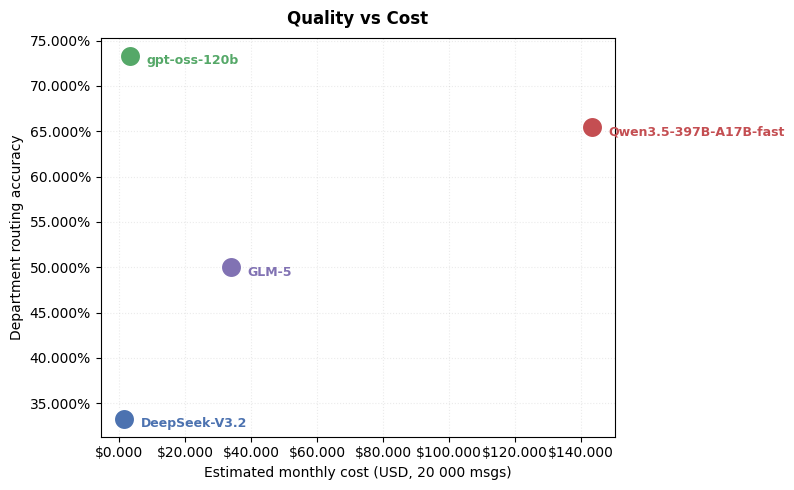

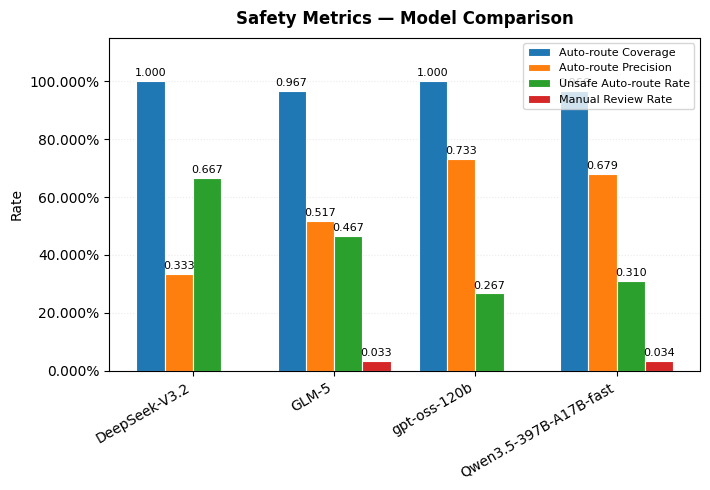

In [54]:
if not comparison_df.empty:
    show_figure(plot_quality_vs_cost(comparison_df))
    show_figure(plot_safety_comparison(comparison_df))

## Step 4 — Run full evaluation on the selected model

Now score **every row** in `df` for the model you chose. This produces the predictions used for the MVP-style decision below.

Because Step 3 already used `await`, Jupyter has an active event loop — use **`await evaluate_model_on_dataframe_async`** here (the sync `evaluate_model_on_dataframe` wraps `asyncio.run`, which conflicts with that).

In [55]:
# Select a model for evaluation

BEST_MODEL = select_best_model(model_runs)
print("Suggested model:", BEST_MODEL)

Suggested model: openai/gpt-oss-120b


In [56]:
# Configure system prompt

SYSTEM_PROMPT = """
You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.
"""

In [57]:
client = create_client(api_key, model=BEST_MODEL)

selected_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

## Step 5 — Check routing quality *(H2)*

Focus on three routing metrics:
- **Department accuracy**: share of tickets routed to the correct department. Higher is better.
- **Category accuracy**: share of tickets with the correct category label. Useful for error analysis, but department routing is the main business objective.

Working target for this module: roughly **>= 85% department accuracy** before considering baseline routing strong enough for the next step.

In [58]:
display_quality_metrics(quality_metrics=selected_run.quality_metrics)

,Department accuracy,Category accuracy,Rows evaluated
0,0.57,0.65,100.0


## Step 6 — Check safety under a simple review rule

**Policy:** **High** confidence → candidate for auto-route; **everything else** → human review.

Safety metrics in this step:
- **auto_route_coverage**: share of tickets marked `High` (could be auto-routed).
- **auto_route_precision**: correctness rate inside that auto-routed slice.
- **unsafe_auto_route_rate**: share of all tickets that would be wrongly auto-routed under this policy (key safety risk metric).
- **manual_review_rate**: share still sent to human review.

Threshold interpretation for this module:
- We require **unsafe_auto_route_rate <= 3%** (`unsafe_auto_route_rate_pass=0.03`) before considering this policy safe enough for MVP-style automation.

In [59]:
sm = compute_safety_metrics(df, selected_run.predictions)
display_safety_metrics(safety_metrics=sm)

,Auto-route coverage,Auto-route precision,Unsafe auto-route rate,Manual review rate
0,0.97,0.588,0.4,0.03


> ⚠️ **Interpreting confidence as a safety signal**
>
> Confidence is useful only if it is **calibrated**: when the model says `High`, it should be correct much more often than average.
>
> Warning pattern: **high auto-route coverage** (many tickets marked `High`) together with **high unsafe auto-route rate** means confidence-gating is not providing real safety.
>
> **What this means for Candlekeep:** this is not only a quality issue, but a trust/control issue. If high-confidence routing is still frequently wrong, reduce automation and improve the system (prompt, examples, and label quality) before expanding auto-routing.
>
> Practical check: compare **high-confidence precision** (accuracy within the auto-routed slice) vs overall **department accuracy**. If the gap is small, confidence is not yet a strong decision signal.


## Step 7 — Check cost at Candlekeep scale *(H6)*

Cost is evaluated at Candlekeep operating volume, not just per-request intuition.
Focus on:
- **cost per 1,000 messages** for practical unit economics,
- **monthly/annual projection** at the configured volume,
- and whether values are **measured** (from observed token usage) or **estimated** (from pricing assumptions).

We break the calculation into transparent steps: assumptions, token-level unit economics, and monthly/annual projection.

Formulas used:
```text
input_cost_per_message  = avg_input_tokens_per_message  * input_price_per_1M  / 1_000_000
output_cost_per_message = avg_output_tokens_per_message * output_price_per_1M / 1_000_000
cost_per_message        = input_cost_per_message + output_cost_per_message
monthly_cost            = cost_per_message * monthly_messages
annual_cost             = monthly_cost * 12
``` 


In [60]:
display_cost_metrics(cost_metrics=selected_run.cost_metrics)

,"Cost per 1,000 messages (USD)",Monthly cost (USD),Annual cost (USD)
0,0.173,3.452,41.427


This makes each input explicit before projecting monthly and annual totals.

In [61]:
display_cost_breakdown(
    model=BEST_MODEL,
    cost_metrics=selected_run.cost_metrics,
    monthly_messages=MONTHLY_MESSAGES,
)

,Assumption,Value
0,Model,openai/gpt-oss-120b
1,Messages per month,20000
2,Avg input tokens per message,178.0
3,Avg output tokens per message,243.19
4,Input price (USD / 1M tokens),0.15
5,Output price (USD / 1M tokens),0.6
6,Cost source,measured


,Token type,Avg tokens / message,Price (USD / 1M tokens),Cost / message (USD)
0,Input,178.00,0.15,0.000027
1,Output,243.19,0.60,0.000146
2,Total,421.19,NaN,0.000173


In [62]:
display_cost_projection(
    cost_metrics=selected_run.cost_metrics,
    monthly_messages=MONTHLY_MESSAGES,
)

,Metric,Value
0,Messages per month,20000.000000
1,Cost per message (USD),0.000173
2,Monthly cost (USD),3.452280
3,Annual cost (USD),41.427360


At 20,000 messages/month, projected cost is $3.45/month (~$41.43/year).


## Step 8 — Check speed feasibility *(H7)*

This step evaluates **LLM inference latency only** (model call speed in this notebook), not full end-to-end first-response time.

What to read here:
- **median_latency_ms**: typical model response time.
- **p95_latency_ms**: tail latency (slower edge cases).

Use these as technical feasibility indicators for model responsiveness.
Operational response-time targets (for example, business SLA first-response time) require broader workflow measurement and are out of scope for this notebook step.

If `median_latency_ms` is missing, latency was not measured in this run.


In [63]:
display_latency_metrics(latency_metrics=selected_run.latency_metrics)

,Median latency (ms),p95 latency (ms),Latency source
0,1473.093,2028.891,measured


## Step 9 — Review the full evaluation summary

Combine quality, safety, cost, and speed into a single MVP-style summary: **`display_mvp_decision`** shows a table (status + thresholds per dimension) and the text recommendation — easier to read than raw JSON.

In [64]:
decision = evaluate_decision(
    run=selected_run,
    thresholds=DECISION_THRESHOLDS,
)
display_mvp_decision(decision=decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.570,0.85
1,Category Accuracy,fail,0.650,0.85
2,Unsafe Auto Route Rate,fail,0.400,0.03
3,Monthly Cost Usd,pass,3.452,1000.00
4,P95 Latency Ms,pass,2028.891,5000.00


## Summary

Notebook A establishes a **baseline**: measure current routing quality, safety, cost, and latency before any optimization.

At this stage, first-run misses are expected. The baseline prompt is intentionally simple, so one or more thresholds may fail even when the workflow is functioning correctly.

Because this is a baseline checkpoint, **Improve and re-test** is usually the default next step when results are weak or borderline. A hard stop is reserved for cases where constraints clearly cannot be met.

Notebook B should then focus on:
- prompt refinement from observed mistakes,
- high confident errors analytis,
- targeted label-quality improvements,
- few-shot ablation and trade-off analysis (quality vs cost/latency).

In short: Notebook A defines the gap; Notebook B is where you reduce it with controlled iteration.
